In [8]:
import pickle
from main import Result
from src import SBsim
import pandas as pd

In [2]:
open_file = open("/home/gkittles/SB_DRIPP_Results/1_31_25_Double_Gib/test_results87_0.83_1.dat", "rb")
obj = pickle.load(open_file)

In [3]:
print(obj.best_solution)

In [4]:
print(obj.best_solution[0].L)

[<ptreeopt.tree.Feature object at 0x7faed2ab3230>, <ptreeopt.tree.Action object at 0x7faed2ab3380>, <ptreeopt.tree.Action object at 0x7fafcc0b7110>]


In [5]:
import networkx as nx
import matplotlib.pyplot as plt
import re

def plot_trees(ptrees):
    fig, axes = plt.subplots(1, len(ptrees), figsize=(30, 6))
    if len(ptrees) == 1:
        axes = [axes]
    
    for ax, ptree in zip(axes, ptrees):
        G = nx.DiGraph()
        pos = {}
        labels = {}
        edge_labels = {}
        
        def add_nodes_edges(node, parent=None, pos_x=0, pos_y=0, depth=1, is_left=None):
            node_id = id(node)
            pos[node_id] = (pos_x, -pos_y)
            labels[node_id] = re.sub(r' \(\d+\.\d+%\)', '', str(node))  # Remove percentage format
            G.add_node(node_id)
            
            if parent is not None:
                G.add_edge(id(parent), node_id)
                edge_labels[(id(parent), node_id)] = "True" if is_left else "False"
            
            if hasattr(node, 'l') and node.l:
                add_nodes_edges(node.l, node, pos_x - 1 / depth, pos_y + 1, depth + 1, is_left=True)
            if hasattr(node, 'r') and node.r:
                add_nodes_edges(node.r, node, pos_x + 1 / depth, pos_y + 1, depth + 1, is_left=False)
        
        add_nodes_edges(ptree.root, is_left=None)
        axes[0].set_title('Deploy Centralized')
        axes[1].set_title('Deploy Decentralized')
        axes[2].set_title('Curtailment')
        axes[3].set_title('Decommision Centralized')
        axes[4].set_title('Decommision Decentralized')
        
        nx.draw(G, pos, with_labels=True, labels=labels, node_size=2000, node_color='lightblue', font_size=8, edge_color='gray', ax=ax)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, ax=ax)
    
    plt.show()


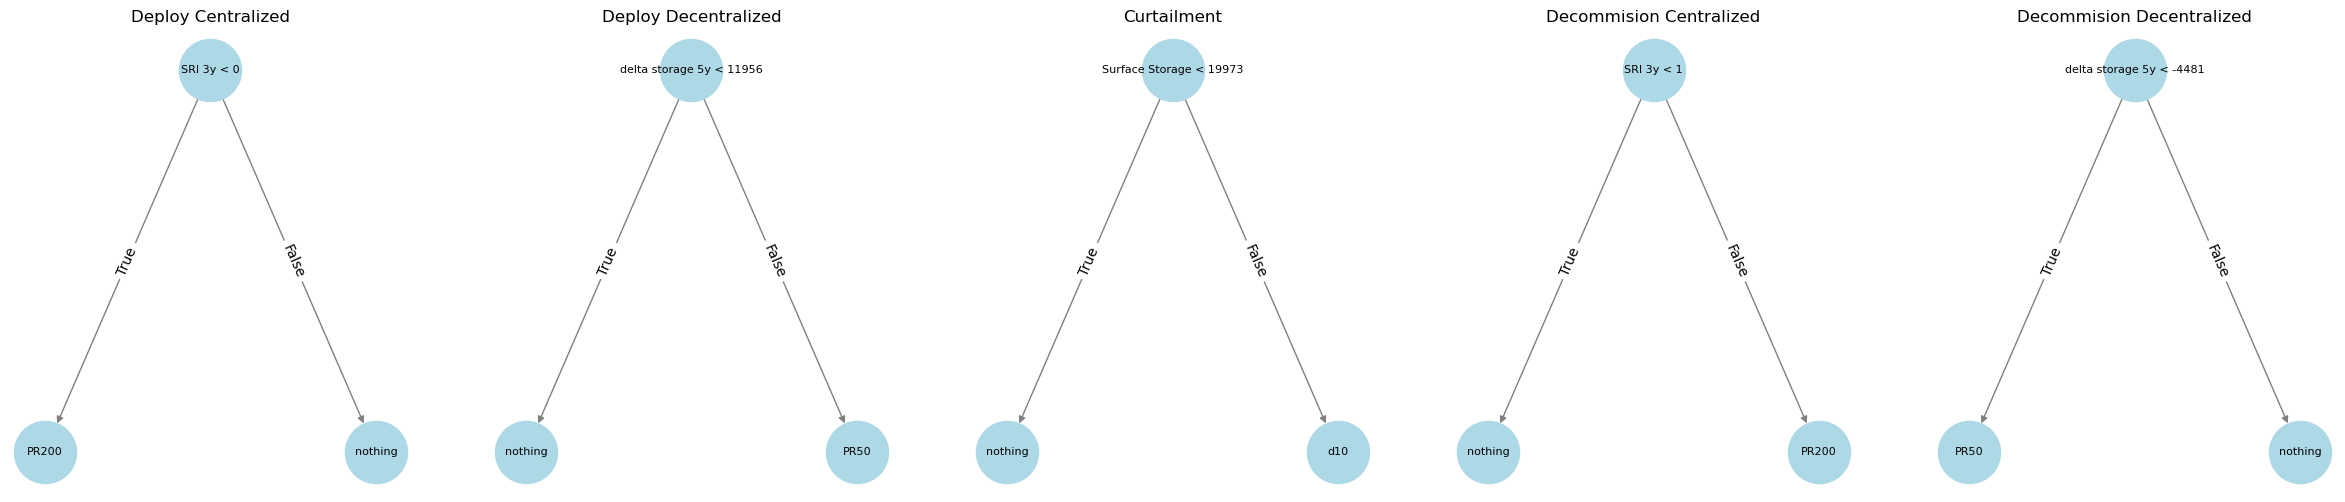

In [6]:
plot_trees(obj.best_solution)

In [10]:
# set optimization parameters
class OptimizationParameters(object):
    def __init__(self):
        self.cores    = 36 # this value is used only in the full scale optimization
        self.nseeds   = 1
        self.nobjs    = 1
        self.drought_type = [87, 0.83, 2] # set drought type here [Persistence (months), Intensity (unitless), Frequency (droughts/100 years)]

#initialize action table
action = [] #Action Name
capacity = [] #Capacity (Acre-Feet/Month)
om = [] #Operation and Maintenance Costs (Million Dollars/ Acre-Feet/ Year)
cx = [] #CAPEX (Million Dollars)
lifetime = [] #Years
t_depl = [] #Time to Deployment (Month)
action_type = [] # types 1: Deploy Centralized Infrastructure, 2: Commision Decentralized Infrastructure, 3: Decommission Centralized Infrastructure, 4: Decommission Centralized Infrastructure, 5: Conservation

#Read the action table
df_actions_table = pd.read_csv("data/actions_table.csv")
action = df_actions_table['action'].values
capacity = df_actions_table['capacity (af/month)'].values
om = df_actions_table['OPEX ($10^6/af/year)'].values
cx = df_actions_table['CAPEX($10^6)'].values
t_depl = df_actions_table['time to deployment (month)'].values
lifetime = df_actions_table['lifetime (year)'].values
action_type = [int(val) for val in df_actions_table['action_type'].values]

action_name = [[], [], [], [], []]
i = 0
for act in action:
        action_name[action_type[i]].extend( [act] )
        i += 1

opt_par = OptimizationParameters()
model_sim = SBsim(opt_par, action_name, capacity, om, cx, t_depl, lifetime) 
log = model_sim.simulate(obj.best_solution, 0)

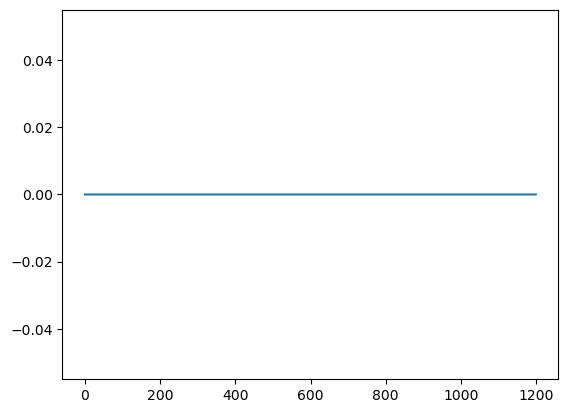

In [14]:
plt.plot(log.reduction_magn)

In [ ]:
plt.plot()